# JEPA progress writeup: complete Stage B, pooling diagnosis, and study readiness

This August 7 update closes a documentation gap in writeup 04, presents the complete
three-run Stage B record, and separates historical measurements from software that is
ready for a planned GaitLU scaling study. It does not report a launched scaling study.

A **JEPA loss** measures how well a predictor estimates hidden target features from
visible context features; lower is better for that prediction task. **Effective rank**
summarizes how many feature directions are meaningfully used, and its ratio divides by
the 384-dimensional maximum. The **historical wrong-context gap** is altered-context
loss minus correct-context loss, so a positive value means substitution made prediction
worse. **GFC-v2** is a 16-query, eight-cell factor-completion retrieval protocol with
fractional credit for ties. **Fixed exposure** means every scaling run processes the
same number of configured training examples even when its unique-data pool differs.


In [1]:
from pathlib import Path
import json
import os
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pandas as pd


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / 'pyproject.toml').is_file() and (candidate / 'results').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the cody-jepa repository root')


REPO_ROOT = find_repo_root()
SOURCE_ROOT = REPO_ROOT / 'src'
if str(SOURCE_ROOT) not in sys.path:
    sys.path.insert(0, str(SOURCE_ROOT))

IMAGE_DIR = Path(os.environ.get(
    'CODY_JEPA_WRITEUP_IMAGE_DIR', REPO_ROOT / 'docs' / 'images'
)).expanduser().resolve()
OUTPUT_DIR = Path(os.environ.get(
    'CODY_JEPA_REPRO_OUTPUT_DIR',
    REPO_ROOT / 'results' / 'generated' / 'writeup-08-07',
)).expanduser().resolve()
STUDY_RECORD_PATH = (
    REPO_ROOT / 'results' / 'generated' / 'writeup-08-07' / 'gaitlu-study-record.json'
).resolve()
IMAGE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

HISTORY_PATH = REPO_ROOT / 'results' / 'checkpoint_histories.csv'
METADATA_PATH = REPO_ROOT / 'results' / 'checkpoint_histories.json'
SUMMARY_PATH = REPO_ROOT / 'results' / 'phase1_summary.csv'
DIAGNOSIS_PATH = REPO_ROOT / 'results' / 'context_diagnosis.json'
SCALING_CONFIG_PATH = REPO_ROOT / 'configs' / 'train' / 'gaitlu_scaling.json'
required_inputs = [
    HISTORY_PATH, METADATA_PATH, SUMMARY_PATH, DIAGNOSIS_PATH,
    SCALING_CONFIG_PATH, STUDY_RECORD_PATH,
]
missing = [path for path in required_inputs if not path.is_file()]
if missing:
    raise FileNotFoundError(f'Missing required writeup inputs: {missing}')

mpl.rcParams.update({
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 120,
    'font.size': 10,
    'svg.fonttype': 'none',
    'svg.hashsalt': 'cody-jepa-writeup-08-07-v1',
})
print(f'Repository: {REPO_ROOT}')
print(f'Images: {IMAGE_DIR}')
print(f'Exact values: {OUTPUT_DIR}')


Repository: /Users/theodoremui/dev/cody-jepa
Images: /Users/theodoremui/dev/cody-jepa/docs/images
Exact values: /Users/theodoremui/dev/cody-jepa/results/generated/writeup-08-07


## Correction and experiment lineage

Writeup 04 inadvertently omitted `b00-clip-var` from its hard-coded Stage B run list
and therefore stated that no compact b00 result was present. The tracked histories and
summary do contain b00. It is not new training and it is not an independent
replication. It is the same-seed, 100-epoch duration check for the medium-mask,
clip-variance configuration whose representation diagnostics resemble a07.

The three Stage B runs answer different configuration questions. b00 extends the a07
configuration in duration, b01 uses light masking without clip variance, and b02
combines light masking with clip variance. All use seed 0, 3,900 optimizer steps, and
evaluation every two epochs.


In [2]:
STAGE_B_RUNS = ('b00-clip-var', 'b01-mask-light', 'b02-mask-light-clip-var')
RUN_LABELS = {
    'b00-clip-var': 'b00 clip variance',
    'b01-mask-light': 'b01 light mask',
    'b02-mask-light-clip-var': 'b02 light mask + clip variance',
}
RUN_COLORS = {
    'b00-clip-var': '#6f4c9b',
    'b01-mask-light': '#31688e',
    'b02-mask-light-clip-var': '#a64b00',
}
RUN_LINESTYLES = {
    'b00-clip-var': '-',
    'b01-mask-light': '--',
    'b02-mask-light-clip-var': ':',
}

metadata_payload = json.loads(METADATA_PATH.read_text(encoding='utf-8'))
run_metadata = {row['run_id']: row for row in metadata_payload['runs']}
summary = pd.read_csv(SUMMARY_PATH, float_precision='round_trip').set_index('run_id')
history = pd.read_csv(HISTORY_PATH, float_precision='round_trip')

for run_id in STAGE_B_RUNS:
    meta = run_metadata[run_id]
    config = meta['config']
    if meta['completed_epochs'] != 100 or meta['global_step'] != 3900:
        raise AssertionError(f'{run_id}: expected 100 epochs and 3,900 steps')
    if config['seed'] != 0 or config['num_epochs'] != 100 or config['steps'] != 3900:
        raise AssertionError(f'{run_id}: unexpected seed or duration')
    if config['eval_every_epochs'] != 2:
        raise AssertionError(f'{run_id}: expected evaluation every two epochs')
    if meta['evaluation_epochs'] != list(range(2, 101, 2)):
        raise AssertionError(f'{run_id}: incomplete evaluation schedule')
    rows = history.loc[history['run_id'].eq(run_id) & history['val_loss'].notna()]
    if len(rows) != 50:
        raise AssertionError(f'{run_id}: expected 50 evaluation rows')
    if rows['epoch'].astype(int).tolist() != list(range(2, 101, 2)):
        raise AssertionError(f'{run_id}: evaluation epochs are not canonical')
    if rows['step'].astype(int).tolist() != [39 * epoch for epoch in range(2, 101, 2)]:
        raise AssertionError(f'{run_id}: evaluation steps disagree with epochs')
    required_metrics = [
        'val_loss', 'val_cosine', 'val_effective_rank', 'val_effective_rank_ratio',
        'val_subject_balanced_context_shuffle_loss_gap',
    ]
    if not np.isfinite(rows[required_metrics].to_numpy(dtype=float)).all():
        raise AssertionError(f'{run_id}: evaluation metrics must all be finite')
    if not rows['val_effective_rank_ratio'].between(0, 1).all():
        raise AssertionError(f'{run_id}: effective-rank ratios must lie in [0, 1]')
    if not rows['val_cosine'].between(-1, 1).all():
        raise AssertionError(f'{run_id}: cosine similarities must lie in [-1, 1]')
    if int(summary.loc[run_id, 'seed']) != 0 or int(summary.loc[run_id, 'completed_epochs']) != 100:
        raise AssertionError(f'{run_id}: summary contract disagrees with metadata')

expected_configs = {
    'b00-clip-var': ('medium', 1.0),
    'b01-mask-light': ('light', 0.0),
    'b02-mask-light-clip-var': ('light', 1.0),
}
for run_id, (mask, clip_var) in expected_configs.items():
    config = run_metadata[run_id]['config']
    if config['mask_preset'] != mask or config['clip_var_coef'] != clip_var:
        raise AssertionError(f'{run_id}: configuration identity mismatch')

a07_config = run_metadata['a07-clip-var']['config']
for key in ('seed', 'mask_preset', 'clip_var_coef', 'clip_cov_coef', 'lr', 'pred_depth'):
    if run_metadata['b00-clip-var']['config'][key] != a07_config[key]:
        raise AssertionError(f'b00 and a07 disagree on {key}')
print('Validated three Stage B configurations, seeds, durations, steps, and 50-point schedules.')


Validated three Stage B configurations, seeds, durations, steps, and 50-point schedules.


## Complete Stage B trajectories

The curves show every stored evaluation. Circles mark checkpoints selected by the
historical health rule or loss rule; X marks epoch 100. Selected checkpoints are useful
for tracing already-computed downstream summaries, but they mix epochs 18, 88, and 84.
Epoch 100 is the matched Stage B comparison and is therefore the endpoint emphasized
in the interpretation below.


In [3]:
metric_map = {
    'validation_loss': 'val_loss',
    'cosine_similarity': 'val_cosine',
    'effective_rank_ratio': 'val_effective_rank_ratio',
    'raw_subject_balanced_wrong_context_gap':
        'val_subject_balanced_context_shuffle_loss_gap',
}
trajectory = history.loc[
    history['run_id'].isin(STAGE_B_RUNS) & history['val_loss'].notna(),
    ['run_id', 'epoch', 'step', *metric_map.values()],
].copy()
trajectory = trajectory.rename(columns={value: key for key, value in metric_map.items()})
trajectory['run_label'] = trajectory['run_id'].map(RUN_LABELS)
trajectory = trajectory[
    ['run_id', 'run_label', 'epoch', 'step', *metric_map.keys()]
].sort_values(['run_id', 'epoch'])
plotted_metric_columns = list(metric_map.keys())
if not np.isfinite(trajectory[plotted_metric_columns].to_numpy(dtype=float)).all():
    raise AssertionError('Stage B trajectory metrics must all be finite')
if trajectory['raw_subject_balanced_wrong_context_gap'].le(0).any():
    raise AssertionError('Context gaps must be positive for the logarithmic axis')
trajectory_path = OUTPUT_DIR / 'stage-b-complete-trajectories.csv'
trajectory.to_csv(trajectory_path, index=False, float_format='%.17g')

summary_to_history = {
    'validation_loss': 'validation_loss',
    'effective_rank': None,
    'effective_rank_ratio': 'effective_rank_ratio',
    'wrong_context_gap': 'raw_subject_balanced_wrong_context_gap',
}
selected_rows = []
for run_id in STAGE_B_RUNS:
    selected_epoch = int(summary.loc[run_id, 'selected_epoch'])
    observed = trajectory.loc[
        trajectory['run_id'].eq(run_id) & trajectory['epoch'].eq(selected_epoch)
    ]
    if len(observed) != 1:
        raise AssertionError(f'{run_id}: selected epoch missing or duplicated')
    observed = observed.iloc[0]
    history_row = history.loc[
        history['run_id'].eq(run_id) & history['epoch'].eq(selected_epoch)
        & history['val_loss'].notna()
    ].iloc[0]
    for summary_key, trajectory_key in summary_to_history.items():
        actual = (
            history_row['val_effective_rank'] if summary_key == 'effective_rank'
            else observed[trajectory_key]
        )
        if not np.isclose(summary.loc[run_id, summary_key], actual, rtol=1e-12, atol=1e-14):
            raise AssertionError(f'{run_id}: {summary_key} disagrees with history')
    selected_rows.append({
        'run_id': run_id,
        'run_label': RUN_LABELS[run_id],
        'checkpoint_rule': summary.loc[run_id, 'selected_checkpoint'],
        'selected_epoch': selected_epoch,
        'step': int(observed['step']),
        'validation_loss': summary.loc[run_id, 'validation_loss'],
        'cosine_similarity': observed['cosine_similarity'],
        'effective_rank': summary.loc[run_id, 'effective_rank'],
        'effective_rank_ratio': summary.loc[run_id, 'effective_rank_ratio'],
        'raw_subject_balanced_wrong_context_gap': summary.loc[run_id, 'wrong_context_gap'],
    })
selected_values = pd.DataFrame(selected_rows)
selected_path = OUTPUT_DIR / 'stage-b-selected-checkpoint-values.csv'
selected_values.to_csv(selected_path, index=False, float_format='%.17g')

endpoint_values = trajectory.loc[trajectory['epoch'].eq(100)].copy()
endpoint_values['effective_rank'] = [
    history.loc[
        history['run_id'].eq(run_id) & history['epoch'].eq(100)
        & history['val_loss'].notna(), 'val_effective_rank'
    ].iloc[0]
    for run_id in endpoint_values['run_id']
]
endpoint_values = endpoint_values[
    ['run_id', 'run_label', 'epoch', 'step', 'validation_loss', 'cosine_similarity',
     'effective_rank', 'effective_rank_ratio', 'raw_subject_balanced_wrong_context_gap']
]
endpoint_path = OUTPUT_DIR / 'stage-b-epoch-100-values.csv'
endpoint_values.to_csv(endpoint_path, index=False, float_format='%.17g')
display(endpoint_values.reset_index(drop=True))


,run_id,run_label,epoch,step,validation_loss,cosine_similarity,effective_rank,effective_rank_ratio,raw_subject_balanced_wrong_context_gap
0,b00-clip-var,b00 clip variance,100,3900,0.533895,0.730590,57.783958,0.150479,0.064604
1,b01-mask-light,b01 light mask,100,3900,0.382306,0.774615,10.916805,0.028429,0.000355
2,b02-mask-light-clip-var,b02 light mask + clip variance,100,3900,0.555403,0.705033,75.869934,0.197578,0.113356


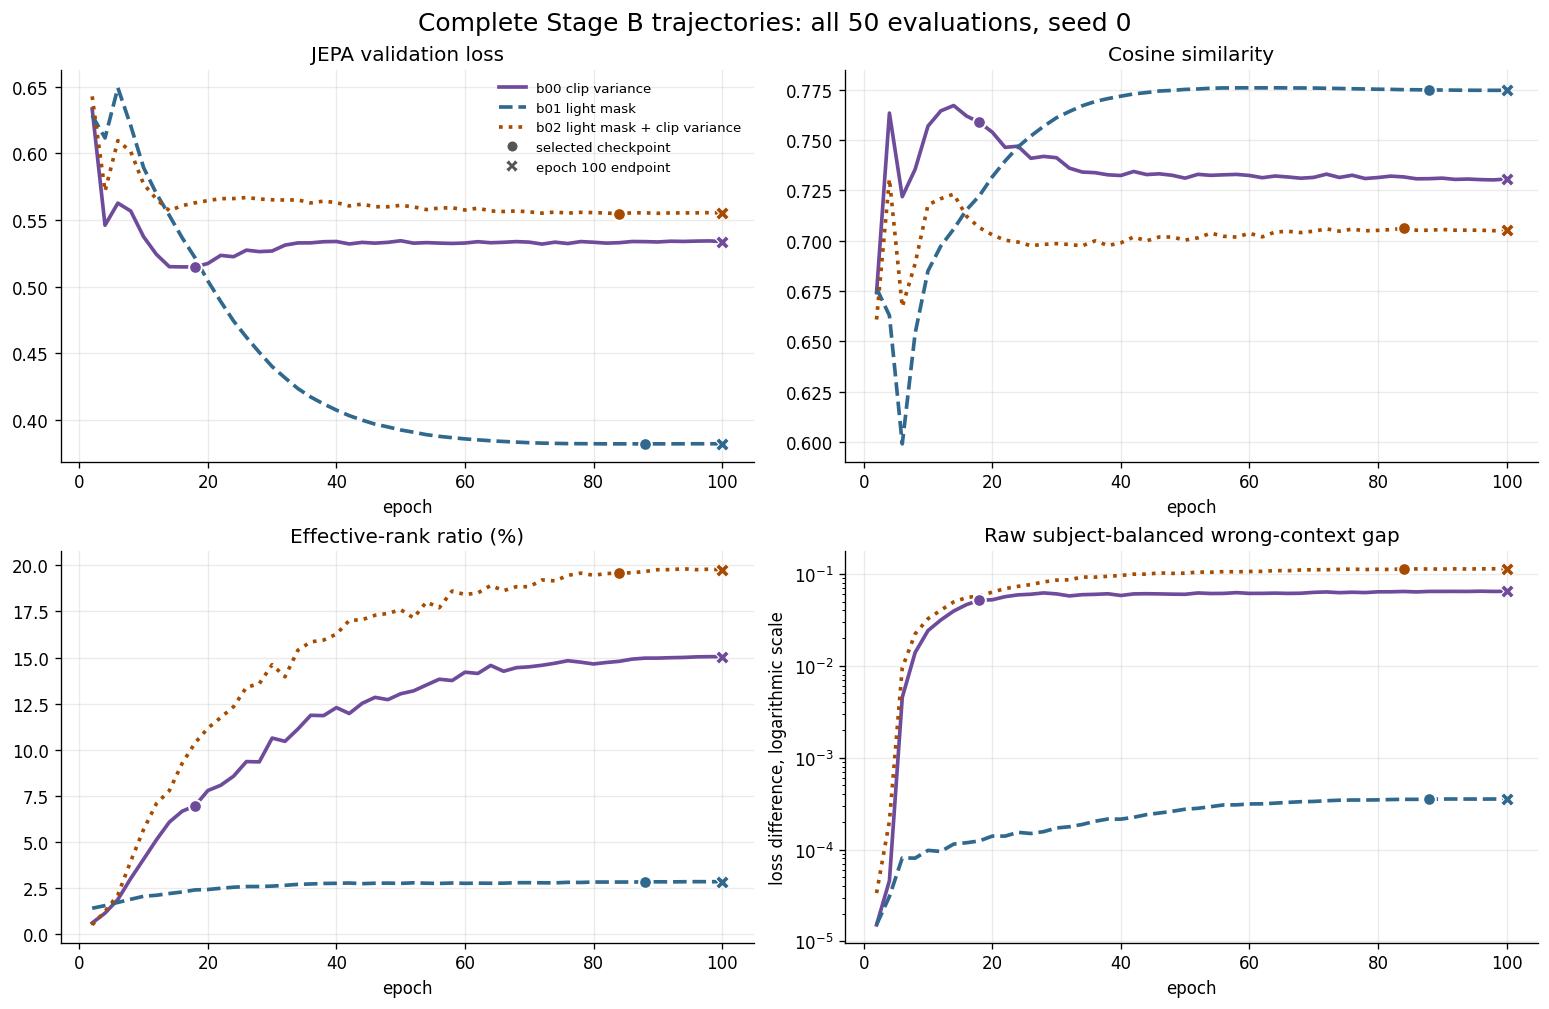

/Users/theodoremui/dev/cody-jepa/docs/images/stage-b-complete-trajectories.png
/Users/theodoremui/dev/cody-jepa/results/generated/writeup-08-07/stage-b-complete-trajectories.csv
/Users/theodoremui/dev/cody-jepa/results/generated/writeup-08-07/stage-b-selected-checkpoint-values.csv
/Users/theodoremui/dev/cody-jepa/results/generated/writeup-08-07/stage-b-epoch-100-values.csv


In [4]:
plot_specs = [
    ('validation_loss', 'JEPA validation loss', 1.0),
    ('cosine_similarity', 'Cosine similarity', 1.0),
    ('effective_rank_ratio', 'Effective-rank ratio (%)', 100.0),
    ('raw_subject_balanced_wrong_context_gap',
     'Raw subject-balanced wrong-context gap', 1.0),
]
fig, axes = plt.subplots(2, 2, figsize=(12.8, 8.3), constrained_layout=True)
for ax, (metric, title, scale) in zip(axes.flat, plot_specs):
    for run_id in STAGE_B_RUNS:
        rows = trajectory.loc[trajectory['run_id'].eq(run_id)]
        ax.plot(rows['epoch'], scale * rows[metric], color=RUN_COLORS[run_id],
                linestyle=RUN_LINESTYLES[run_id], linewidth=2.2,
                label=RUN_LABELS[run_id])
        selected_epoch = int(summary.loc[run_id, 'selected_epoch'])
        selected_point = rows.loc[rows['epoch'].eq(selected_epoch)].iloc[0]
        endpoint = rows.iloc[-1]
        ax.scatter(selected_epoch, scale * selected_point[metric], marker='o', s=58,
                   facecolor=RUN_COLORS[run_id], edgecolor='white', linewidth=1.2, zorder=4)
        ax.scatter(100, scale * endpoint[metric], marker='X', s=68,
                   color=RUN_COLORS[run_id], edgecolor='white', linewidth=0.7, zorder=5)
    ax.set_title(title)
    ax.set_xlabel('epoch')
    ax.grid(True, alpha=0.25)
axes[1, 1].set_yscale('log')
axes[1, 1].set_ylabel('loss difference, logarithmic scale')
run_handles = [Line2D([0], [0], color=RUN_COLORS[run_id],
                      linestyle=RUN_LINESTYLES[run_id], lw=2.2,
                      label=RUN_LABELS[run_id]) for run_id in STAGE_B_RUNS]
point_handles = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor='#555555',
           markeredgecolor='white', markersize=7, label='selected checkpoint'),
    Line2D([0], [0], marker='X', color='none', markerfacecolor='#555555',
           markeredgecolor='white', markersize=8, label='epoch 100 endpoint'),
]
axes[0, 0].legend(handles=run_handles + point_handles, frameon=False, fontsize=8)
fig.suptitle('Complete Stage B trajectories: all 50 evaluations, seed 0', fontsize=15)
trajectory_image = IMAGE_DIR / 'stage-b-complete-trajectories.png'
fig.savefig(trajectory_image, dpi=180, bbox_inches='tight')
plt.show()
print(trajectory_image)
print(trajectory_path)
print(selected_path)
print(endpoint_path)


### Matched endpoint reading

At epoch 100, b00 and b02 retain much broader pooled features and much larger
wrong-context responses than b01. b00 ends at a 15.05% effective-rank ratio and a
0.06460 raw gap; b02 ends at 19.76% and 0.11336. b01 ends at only 2.84% and 0.000355,
although its JEPA loss is lower. This is a descriptive tradeoff, not evidence that one
checkpoint is generally better.

b00's selected epoch remains relevant only to summaries historically computed from
that checkpoint. Its existence corrects the record and strengthens the duration
comparison. It does not add a new seed, a full phenotype replication, or an independent
replication of a07.


## Context and pooling diagnosis

This earlier diagnostic belongs to the Phase 0 baseline best-loss checkpoint at epoch
80, not to any Stage B run. It fixed each masked target and changed the supplied
context. Its bootstrap intervals resample participants. The foreground rule labels a target token
by whether corresponding image content exceeds a fixed 0.05 pixel threshold; it is a
measurement rule, not a semantic segmentation model. Pooled features average a
recording into one vector, while token features retain separate space-time locations.


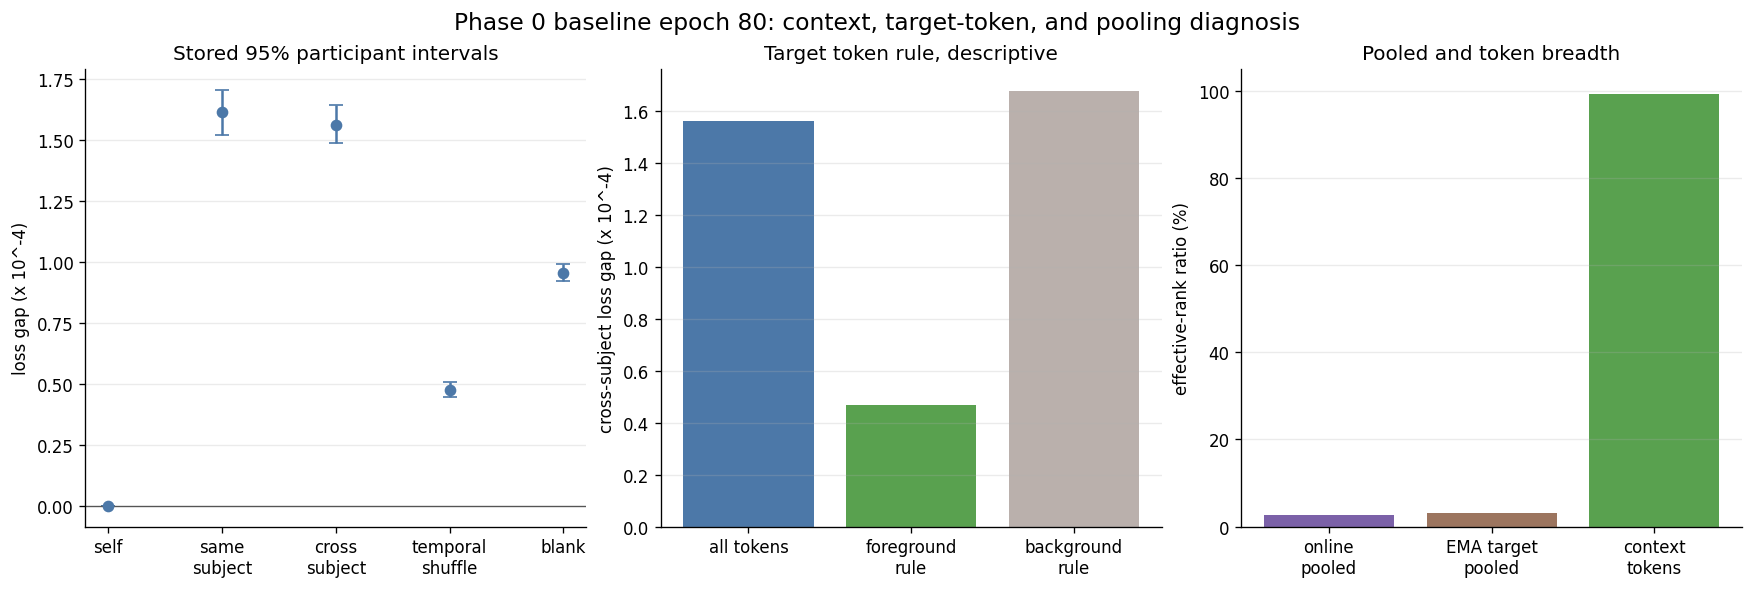

/Users/theodoremui/dev/cody-jepa/docs/images/context-pooling-foreground-diagnosis.png
/Users/theodoremui/dev/cody-jepa/results/generated/writeup-08-07/context-pooling-foreground-diagnosis.csv


In [5]:
diagnosis = json.loads(DIAGNOSIS_PATH.read_text(encoding='utf-8'))
checkpoint_label = diagnosis['checkpoint_label']
if checkpoint_label != 'phase0-best-loss-epoch-80':
    raise AssertionError('Unexpected context-diagnosis checkpoint')
bootstrap = diagnosis['participant_bootstrap']
if bootstrap != {'resamples': 10000, 'seed': 0, 'confidence_level': 0.95}:
    raise AssertionError('Unexpected stored participant bootstrap contract')

diagnosis_rows = []
for row in diagnosis['context_substitution']:
    if row['rows'] != 3744:
        raise AssertionError('Context substitution row count changed')
    interval_values = np.asarray([
        row['interval_low'], row['participant_mean_gap'], row['interval_high']
    ], dtype=float)
    if not np.isfinite(interval_values).all() or not (
        interval_values[0] <= interval_values[1] <= interval_values[2]
    ):
        raise AssertionError(f"Invalid interval for {row['condition']}")
    diagnosis_rows.append({
        'checkpoint_label': checkpoint_label,
        'panel': 'context substitution', 'item': row['condition'],
        'estimate': row['participant_mean_gap'], 'interval_low': row['interval_low'],
        'interval_high': row['interval_high'], 'rows': row['rows'],
        'dimension': np.nan, 'unit': 'loss difference',
    })

foreground = diagnosis['foreground']
foreground_keys = ('all_token_gap', 'foreground_only_gap', 'background_only_gap')
if not np.isfinite([foreground[key] for key in foreground_keys]).all():
    raise AssertionError('Foreground diagnosis gaps must all be finite')
if not np.isclose(foreground['all_token_gap'], next(
    row['participant_mean_gap'] for row in diagnosis['context_substitution']
    if row['condition'] == 'cross_subject'
), rtol=0, atol=1e-15):
    raise AssertionError('All-token gap must equal the cross-subject aggregate')
for item, key in (
    ('all-token rule', 'all_token_gap'),
    ('foreground rule', 'foreground_only_gap'),
    ('background rule', 'background_only_gap'),
):
    diagnosis_rows.append({
        'checkpoint_label': checkpoint_label,
        'panel': 'target token rule', 'item': item, 'estimate': foreground[key],
        'interval_low': np.nan, 'interval_high': np.nan, 'rows': np.nan,
        'dimension': np.nan, 'unit': 'loss difference',
    })

rank_rows = diagnosis['representation_rank']
for row in rank_rows:
    if row['dimension'] != 384:
        raise AssertionError('Unexpected representation dimension')
    if not np.isclose(row['effective_rank'] / row['dimension'], row['ratio'],
                      rtol=2e-5, atol=1e-7):
        raise AssertionError(f"Rank ratio mismatch for {row['representation']}")
    diagnosis_rows.append({
        'checkpoint_label': checkpoint_label,
        'panel': 'representation rank', 'item': row['representation'],
        'estimate': row['ratio'], 'interval_low': np.nan, 'interval_high': np.nan,
        'rows': row['rows'], 'dimension': row['dimension'],
        'unit': 'effective-rank ratio',
    })
diagnosis_values = pd.DataFrame(diagnosis_rows)
expected_conditions = ['self', 'same_subject', 'cross_subject', 'temporal_shuffle', 'blank']
observed_conditions = diagnosis_values.loc[
    diagnosis_values['panel'].eq('context substitution'), 'item'
].tolist()
if observed_conditions != expected_conditions:
    raise AssertionError(f'Unexpected context condition order: {observed_conditions}')
diagnosis_path = OUTPUT_DIR / 'context-pooling-foreground-diagnosis.csv'
diagnosis_values.to_csv(diagnosis_path, index=False, float_format='%.17g')

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.8), constrained_layout=True)
context = diagnosis_values.loc[diagnosis_values['panel'].eq('context substitution')]
x = np.arange(len(context))
center = 1e4 * context['estimate'].to_numpy()
lower = 1e4 * (context['estimate'] - context['interval_low']).to_numpy()
upper = 1e4 * (context['interval_high'] - context['estimate']).to_numpy()
axes[0].errorbar(x, center, yerr=np.vstack([lower, upper]), fmt='o', color='#4c78a8',
                 capsize=4, linewidth=1.5)
axes[0].axhline(0, color='#555555', linewidth=0.8)
axes[0].set_xticks(x, ['self', 'same\nsubject', 'cross\nsubject', 'temporal\nshuffle', 'blank'])
axes[0].set_ylabel('loss gap (x 10^-4)')
axes[0].set_title('Stored 95% participant intervals')
axes[0].grid(True, axis='y', alpha=0.25)

rules = diagnosis_values.loc[diagnosis_values['panel'].eq('target token rule')]
axes[1].bar(np.arange(len(rules)), 1e4 * rules['estimate'],
            color=['#4c78a8', '#59a14f', '#bab0ac'])
axes[1].set_xticks(np.arange(len(rules)), ['all tokens', 'foreground\nrule', 'background\nrule'])
axes[1].set_ylabel('cross-subject loss gap (x 10^-4)')
axes[1].set_title('Target token rule, descriptive')
axes[1].grid(True, axis='y', alpha=0.25)

rank_order = [
    'online_full_view_pooled', 'ema_target_pre_norm_pooled',
    'context_tokens_all_mask_groups',
]
ranks = diagnosis_values.loc[
    diagnosis_values['panel'].eq('representation rank')
].set_index('item').loc[rank_order]
axes[2].bar(np.arange(len(ranks)), 100 * ranks['estimate'],
            color=['#7b61a8', '#9c755f', '#59a14f'])
axes[2].set_xticks(np.arange(len(ranks)), ['online\npooled', 'EMA target\npooled', 'context\ntokens'])
axes[2].set_ylabel('effective-rank ratio (%)')
axes[2].set_ylim(0, 105)
axes[2].set_title('Pooled and token breadth')
axes[2].grid(True, axis='y', alpha=0.25)

fig.suptitle('Phase 0 baseline epoch 80: context, target-token, and pooling diagnosis',
             fontsize=14)
diagnosis_image = IMAGE_DIR / 'context-pooling-foreground-diagnosis.png'
fig.savefig(diagnosis_image, dpi=180, bbox_inches='tight')
plt.show()
print(diagnosis_image)
print(diagnosis_path)


For the Phase 0 baseline best-loss checkpoint at epoch 80, the cross-subject all-token
gap is 0.0001563. Under the stored target-token rules, the
foreground gap is 0.0000467 and the background gap is 0.0001679. These measurements
show a larger response on background-rule tokens, but they do not identify the cue,
prove a background shortcut, or establish causality.

The context-token effective-rank ratio is 99.37%, while the online pooled ratio is
2.72%. Thus token breadth was not preserved in the pooled representation. Averaging is
associated with the observed difference, but this aggregate record does not show that
pooling causally destroyed information.


## GFC-v2 symbolic protocol validation

An oracle here is a hypothetical solver that perfectly recovers a stated subset of
speed, clothing, and direction. The repository compiler constructs the same 16 queries
used by GFC-v2, and the exact enumerator awards fractional top-1 credit across tied
gallery cells. This is a protocol ruler, not model performance.

The comparison below changes only the gallery policy. The sensitivity uses the same
16-query design with both donors excluded. It is not the historical 24-query legacy
protocol and is never used as its label.


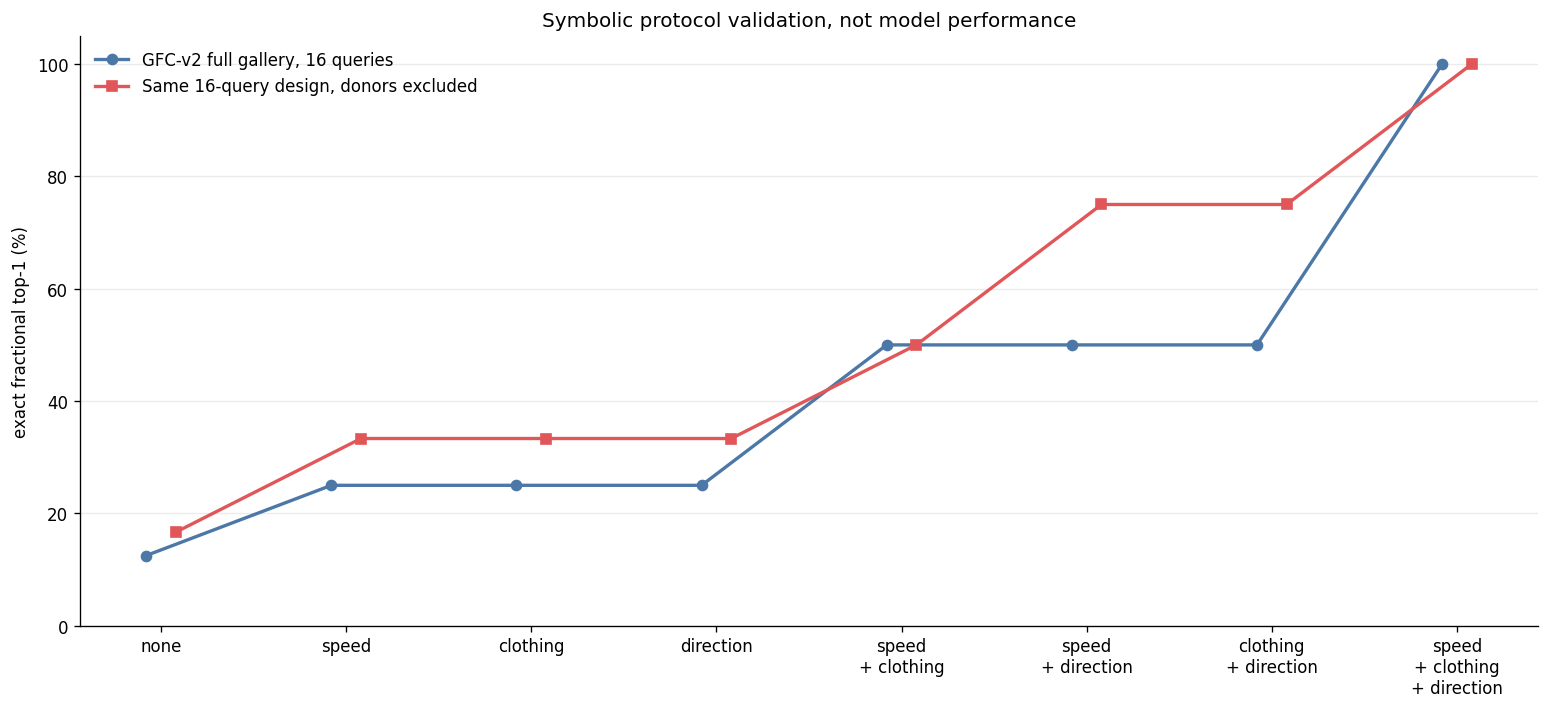

,protocol_label,protocol_name,gallery_policy,gallery_size,query_count,recovered_factors,recovered_factor_count,top1_fraction,top1_decimal,mrr_fraction,mrr_decimal
0,"GFC-v2 full gallery, 16 queries",gfc_v2,retain_all,8,16,none,0,1/8,0.125000,2/9,0.222222
1,"GFC-v2 full gallery, 16 queries",gfc_v2,retain_all,8,16,speed,1,1/4,0.250000,2/5,0.400000
2,"GFC-v2 full gallery, 16 queries",gfc_v2,retain_all,8,16,clothing,1,1/4,0.250000,2/5,0.400000
3,"GFC-v2 full gallery, 16 queries",gfc_v2,retain_all,8,16,direction,1,1/4,0.250000,2/5,0.400000
4,"GFC-v2 full gallery, 16 queries",gfc_v2,retain_all,8,16,speed + clothing,2,1/2,0.500000,2/3,0.666667
5,"GFC-v2 full gallery, 16 queries",gfc_v2,retain_all,8,16,speed + direction,2,1/2,0.500000,2/3,0.666667
6,"GFC-v2 full gallery, 16 queries",gfc_v2,retain_all,8,16,clothing + direction,2,1/2,0.500000,2/3,0.666667
7,"GFC-v2 full gallery, 16 queries",gfc_v2,retain_all,8,16,speed + clothing + direction,3,1,1.000000,1,1.000000
8,"Same 16-query design, donors excluded",gfc_v2,exclude_donors,6,16,none,0,1/6,0.166667,2/7,0.285714
9,"Same 16-query design, donors excluded",gfc_v2,exclude_donors,6,16,speed,1,1/3,0.333333,1/2,0.500000


/Users/theodoremui/dev/cody-jepa/docs/images/gfc-v2-oracle-protocol-comparison.png
/Users/theodoremui/dev/cody-jepa/results/generated/writeup-08-07/gfc-v2-oracle-protocol-comparison.csv


In [6]:
from cody_jepa.evaluation.gfc.oracle import (
    EXCLUDE_DONORS,
    RETAIN_ALL,
    compile_healthgait_gfc_v2_protocol,
    enumerate_oracle_spectrum,
)

protocol_specs = [
    ('GFC-v2 full gallery, 16 queries', RETAIN_ALL),
    ('Same 16-query design, donors excluded', EXCLUDE_DONORS),
]
oracle_rows = []
for protocol_label, gallery_policy in protocol_specs:
    protocol = compile_healthgait_gfc_v2_protocol(gallery_policy=gallery_policy)
    if len(protocol.queries) != 16 or protocol.design.factor_names != (
        'speed', 'clothing', 'direction'
    ):
        raise AssertionError('Unexpected compiled GFC-v2 design')
    expected_gallery = 8 if gallery_policy == RETAIN_ALL else 6
    if any(len(query.gallery) != expected_gallery for query in protocol.queries):
        raise AssertionError('Compiled gallery size mismatch')
    spectrum = enumerate_oracle_spectrum(protocol)
    for entry in spectrum.entries:
        label = 'none' if not entry.recovered_factors else ' + '.join(entry.recovered_factors)
        oracle_rows.append({
            'protocol_label': protocol_label,
            'protocol_name': protocol.name,
            'gallery_policy': gallery_policy,
            'gallery_size': expected_gallery,
            'query_count': len(protocol.queries),
            'recovered_factors': label,
            'recovered_factor_count': len(entry.recovered_factors),
            'top1_fraction': str(entry.top1),
            'top1_decimal': float(entry.top1),
            'mrr_fraction': str(entry.mrr),
            'mrr_decimal': float(entry.mrr),
        })
oracle_values = pd.DataFrame(oracle_rows)
oracle_path = OUTPUT_DIR / 'gfc-v2-oracle-protocol-comparison.csv'
oracle_values.to_csv(oracle_path, index=False, float_format='%.17g')

subset_order = oracle_values.loc[
    oracle_values['gallery_policy'].eq(RETAIN_ALL), 'recovered_factors'
].tolist()
fig, ax = plt.subplots(figsize=(12.8, 5.8), constrained_layout=True)
x = np.arange(len(subset_order))
for offset, (protocol_label, gallery_policy), marker, color in zip(
    (-0.08, 0.08), protocol_specs, ('o', 's'), ('#4c78a8', '#e15759')
):
    rows = oracle_values.loc[
        oracle_values['gallery_policy'].eq(gallery_policy)
    ].set_index('recovered_factors').loc[subset_order]
    ax.plot(x + offset, 100 * rows['top1_decimal'], marker=marker, color=color,
            linewidth=2, markersize=6, label=protocol_label)
ax.set_xticks(x, [label.replace(' + ', '\n+ ') for label in subset_order])
ax.set_ylabel('exact fractional top-1 (%)')
ax.set_ylim(0, 105)
ax.set_title('Symbolic protocol validation, not model performance')
ax.grid(True, axis='y', alpha=0.25)
ax.legend(frameon=False, loc='upper left')
oracle_image = IMAGE_DIR / 'gfc-v2-oracle-protocol-comparison.png'
fig.savefig(oracle_image, dpi=180, bbox_inches='tight')
plt.show()
display(oracle_values)
print(oracle_image)
print(oracle_path)


The full gallery gives the regular 12.5%, 25%, 50%, and 100% top-1 spectrum as zero,
one, two, or three factors are recovered. Donor exclusion raises chance to one sixth
and makes some two-factor oracles asymmetric, reaching 75% instead of 50%. That
sensitivity demonstrates why gallery policy belongs in the protocol definition. It
does not say how a learned encoder performs.


## GaitLU study readiness

The intended design has five independently seeded nested ladders, four nominal rungs
per ladder, and 20 expected runs. Fixed exposure is configured as 128,000 optimizer
updates with effective batch 64, or 8,192,000 examples per run. Horizontal flipping is
disabled because direction is an evaluated factor.

Readiness must not be confused with completion. The codebase implements preparation,
training, launch, and analysis contracts, while corpus preparation, measured pool
sizes, throughput gating, registry freeze, primary training, and outcomes remain
pending. The study record is read directly below and must say `planned`.


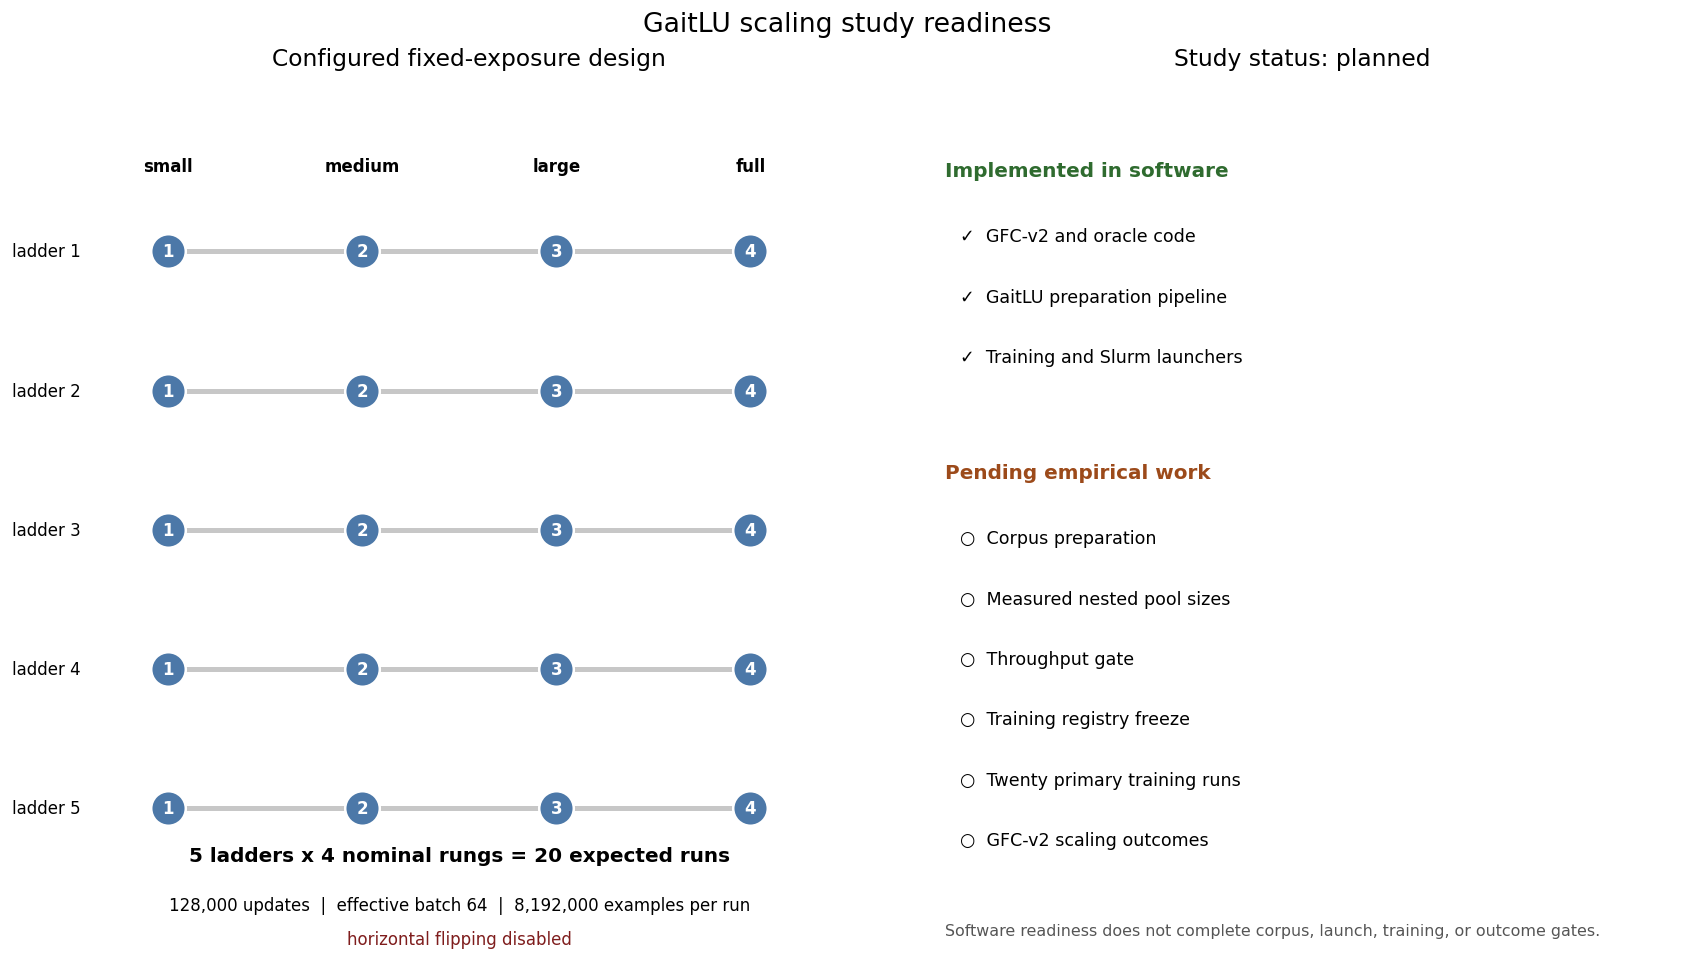

/Users/theodoremui/dev/cody-jepa/docs/images/gaitlu-study-readiness.png
/Users/theodoremui/dev/cody-jepa/docs/images/gaitlu-study-readiness.svg
/Users/theodoremui/dev/cody-jepa/results/generated/writeup-08-07/gaitlu-study-readiness.csv


In [7]:
study_record = json.loads(STUDY_RECORD_PATH.read_text(encoding='utf-8'))
scaling_config = json.loads(SCALING_CONFIG_PATH.read_text(encoding='utf-8'))
from cody_jepa.evaluation.gfc.study import (
    EXPECTED_LADDERS, EXPECTED_MODELS, RUNG_ORDER,
)
expected_study_record = {
    'schema': 1,
    'study_id': 'gaitlu-scaling-v2-2026-08',
    'dataset': 'GaitLU-1M',
    'status': 'planned',
    'architecture': 'cody-jepa-single-stream-masked-v3',
    'config_source': 'configs/train/gaitlu_scaling.json',
    'expected_runs': 20,
    'notes': ('Prospective fixed-exposure scaling study; no completed runs were '
              'present during migration.'),
}
if study_record != expected_study_record:
    raise AssertionError('Tracked GaitLU study record identity or status changed')

ladders, rungs = EXPECTED_LADDERS, len(RUNG_ORDER)
effective_batch = scaling_config['batch_size'] * scaling_config['accumulation_steps']
configured_examples = scaling_config['steps'] * effective_batch
epoch_configured_examples = (
    scaling_config['num_epochs'] * scaling_config['loader_epoch_examples']
)
if configured_examples != epoch_configured_examples:
    raise AssertionError('Step-based and virtual-epoch exposure calculations disagree')
if ladders * rungs != EXPECTED_MODELS or EXPECTED_MODELS != study_record['expected_runs']:
    raise AssertionError('Study implementation and record disagree on expected runs')
expected_contract = {
    'ladders': 5, 'nominal_rungs_per_ladder': 4, 'expected_runs': 20,
    'optimizer_updates_per_run': 128000, 'effective_batch_size': 64,
    'configured_examples_per_run': 8192000, 'horizontal_flip_probability': 0.0,
}
observed_contract = {
    'ladders': ladders, 'nominal_rungs_per_ladder': rungs,
    'expected_runs': study_record['expected_runs'],
    'optimizer_updates_per_run': scaling_config['steps'],
    'effective_batch_size': effective_batch,
    'configured_examples_per_run': configured_examples,
    'horizontal_flip_probability': scaling_config['train_horizontal_flip_prob'],
}
if observed_contract != expected_contract:
    raise AssertionError(f'Scaling contract mismatch: {observed_contract}')

readiness_items = [
    ('Study state', study_record['status'], 'tracked study record'),
    ('GFC-v2 and oracle code', 'implemented in software', 'repository tests'),
    ('GaitLU preparation pipeline', 'implemented in software', 'repository tests'),
    ('Training and Slurm launchers', 'implemented in software', 'repository tests'),
    ('Corpus preparation', 'pending', 'no completion claimed'),
    ('Measured nested pool sizes', 'pending', 'nominal rungs only'),
    ('Throughput gate', 'pending', 'must precede registry freeze'),
    ('Training registry freeze', 'pending', 'launch contract incomplete'),
    ('Twenty primary training runs', 'pending', 'no outcomes available'),
    ('GFC-v2 scaling outcomes', 'pending', 'locked outcome stage not opened'),
]
contract_evidence = {
    'ladders': 'study implementation',
    'nominal_rungs_per_ladder': 'study implementation',
    'expected_runs': 'tracked study record',
    'optimizer_updates_per_run': 'validated config',
    'effective_batch_size': 'validated config',
    'configured_examples_per_run': 'validated config',
    'horizontal_flip_probability': 'validated config',
}
readiness_values = pd.DataFrame([
    {'section': 'design contract', 'item': key, 'value': value,
     'evidence': contract_evidence[key]}
    for key, value in observed_contract.items()
] + [
    {'section': 'readiness', 'item': item, 'value': status, 'evidence': evidence}
    for item, status, evidence in readiness_items
])
readiness_path = OUTPUT_DIR / 'gaitlu-study-readiness.csv'
readiness_values.to_csv(readiness_path, index=False)

fig = plt.figure(figsize=(14, 8), constrained_layout=True)
grid = fig.add_gridspec(1, 2, width_ratios=(1.15, 1.0))
ax_ladders = fig.add_subplot(grid[0, 0])
ax_status = fig.add_subplot(grid[0, 1])

ax_ladders.set_xlim(-0.7, 3.8)
ax_ladders.set_ylim(-1.1, 5.1)
ax_ladders.axis('off')
rung_labels = ('small', 'medium', 'large', 'full')
for ladder in range(ladders):
    y = 4 - ladder
    ax_ladders.plot(range(rungs), [y] * rungs, color='#c7c7c7', linewidth=3, zorder=1)
    for rung in range(rungs):
        ax_ladders.scatter(rung, y, s=430, color='#4c78a8', edgecolor='white',
                           linewidth=1.5, zorder=2)
        ax_ladders.text(rung, y, str(rung + 1), ha='center', va='center',
                        color='white', fontweight='bold', zorder=3)
    ax_ladders.text(-0.45, y, f'ladder {ladder + 1}', ha='right', va='center')
for rung, label in enumerate(rung_labels):
    ax_ladders.text(rung, 4.55, label, ha='center', va='bottom', fontweight='bold')
ax_ladders.text(1.5, -0.38, '5 ladders x 4 nominal rungs = 20 expected runs',
                ha='center', fontsize=12, fontweight='bold')
ax_ladders.text(1.5, -0.73,
                '128,000 updates  |  effective batch 64  |  8,192,000 examples per run',
                ha='center', fontsize=10)
ax_ladders.text(1.5, -0.98, 'horizontal flipping disabled', ha='center',
                fontsize=10, color='#7f1d1d')
ax_ladders.set_title('Configured fixed-exposure design', fontsize=14, pad=20)

ax_status.set_xlim(0, 1)
ax_status.set_ylim(0, 1)
ax_status.axis('off')
ax_status.set_title(f"Study status: {study_record['status']}", fontsize=14, pad=20)
implemented = [item for item, status, _ in readiness_items if status == 'implemented in software']
pending = [item for item, status, _ in readiness_items if status == 'pending']
ax_status.text(0.03, 0.91, 'Implemented in software', color='#2f6b2f',
               fontsize=12, fontweight='bold')
for index, item in enumerate(implemented):
    ax_status.text(0.05, 0.84 - 0.07 * index, f'✓  {item}', fontsize=10.5, va='center')
pending_start = 0.56
ax_status.text(0.03, pending_start, 'Pending empirical work', color='#9c4a1a',
               fontsize=12, fontweight='bold')
for index, item in enumerate(pending):
    ax_status.text(0.05, pending_start - 0.07 * (index + 1), f'○  {item}',
                   fontsize=10.5, va='center')
ax_status.text(0.03, 0.03,
               'Software readiness does not complete corpus, launch, training, or outcome gates.',
               fontsize=9.5, color='#555555', wrap=True)

fig.suptitle('GaitLU scaling study readiness', fontsize=16)
readiness_png = IMAGE_DIR / 'gaitlu-study-readiness.png'
readiness_svg = IMAGE_DIR / 'gaitlu-study-readiness.svg'
fig.savefig(readiness_png, dpi=180, bbox_inches='tight')
fig.savefig(readiness_svg, bbox_inches='tight',
            metadata={'Title': 'GaitLU scaling study readiness', 'Date': None})
svg_text = readiness_svg.read_text(encoding='utf-8')
readiness_svg.write_text(
    '\n'.join(line.rstrip() for line in svg_text.splitlines()) + '\n',
    encoding='utf-8',
)
plt.show()
print(readiness_png)
print(readiness_svg)
print(readiness_path)


The launch contract is not yet complete. In particular, the nominal rungs are design
targets rather than measured eligible counts, and the configured exposure remains
subject to the prespecified throughput gate before a registry is frozen. No primary
run or outcome is inferred from the existence of tested software.


## Completed, pending, and next steps

Completed here: the b00 omission is corrected; all three Stage B histories are shown at
all 50 evaluations; selected and epoch-100 values are exported separately; the stored
pooling diagnosis is bounded; the two 16-query oracle spectra are generated from the
symbolic implementation; and the planned study's software contract is summarized.

Pending, in order:

1. Prepare and validate the GaitLU corpus, exclusions, deduplication, and common holdout.
2. Measure source-safe nested pool sizes for all five ladders.
3. Run the systems pilot and full-pool throughput gate.
4. Freeze the compatible exposure configuration and 20-row registry.
5. Train the five-by-four study without selecting on locked outcomes.
6. Open outcomes only under the frozen GFC-v2 analysis contract.

Claims boundary: these results establish historical configuration differences,
descriptive context and pooling diagnostics, exact symbolic protocol behavior, and
implemented software readiness. They do not establish a causal background shortcut,
information destruction by pooling, successful GaitLU preparation, a frozen launch
contract, completed scaling runs, GFC-v2 model performance, or a benefit from more
unique data.


## Reproduction artifact contract

Every plotted number is exported beside the notebook outputs at full round-trip
precision. The figure directory can be redirected independently from the exact-value
directory, so a clean reproduction can leave checked-in figures untouched. The final
cell verifies that all expected image, SVG, and CSV artifacts exist and are nonempty.


In [8]:
artifacts = [
    trajectory_image,
    diagnosis_image,
    oracle_image,
    readiness_png,
    readiness_svg,
    trajectory_path,
    selected_path,
    endpoint_path,
    diagnosis_path,
    oracle_path,
    readiness_path,
]
empty = [path for path in artifacts if not path.is_file() or path.stat().st_size == 0]
if empty:
    raise AssertionError(f'Missing or empty artifacts: {empty}')
if any('\N{EM DASH}' in path.name for path in artifacts):
    raise AssertionError('Artifact names must not contain em dashes')
print(f'Validated {len(artifacts)} nonempty generated artifacts.')


Validated 11 nonempty generated artifacts.
